# Modeling

### Model Choice

Given the tabular nature of the dataset and the presence of complex nonlinear interactions between features (e.g., time, promotion, product category, and store effects), a tree-based gradient boosting model is adopted.

Specifically, **LightGBM** is used due to its:

- Strong performance on structured/tabular data
- Ability to handle heterogeneous features (numerical + categorical)
- Robustness to feature scaling and missing values
- Efficiency in training on large datasets

LightGBM is particularly suitable for this problem, as it can naturally capture:

- Nonlinear relationships
- Feature interactions (e.g., promotion × family, time × store)
- Piecewise patterns in demand dynamics

This makes it well aligned with the structural patterns identified during EDA and feature engineering.

### Validation Strategy

To evaluate model performance under realistic forecasting conditions, a time-based cross-validation strategy is adopted.

An expanding window approach is used:

- Training data starts from 2013 and progressively expands
- Validation is performed on subsequent future periods
- Each fold simulates a real-world forecasting scenario

This ensures that:

- No future information is used during training
- The model is evaluated on truly unseen data
- Temporal dependencies are preserved

This setup is particularly important for time series problems, where random splits would lead to leakage.

### Training Setup

The model is trained using LightGBM with the following configuration:

- Objective: regression
- Learning rate: 0.05
- Number of estimators: 500
- Number of leaves: 31

Early stopping is applied based on validation RMSE to prevent overfitting.

For each fold:

- The model is trained on historical data
- Predictions are generated on a forward validation window
- Results are stored for out-of-fold (OOF) evaluation

### Evaluation Metrics

Model performance is evaluated using Root Mean Squared Error (RMSE).

Two levels of evaluation are used:

- **Fold-level RMSE**  
  Measures performance on each validation period

- **Out-of-Fold (OOF) RMSE**  
  Aggregates predictions across all folds, providing a more robust estimate of generalization performance

RMSE is chosen because it penalizes large errors more heavily, which is important in retail forecasting where demand spikes are critical.

In [1]:
###read the data
import pandas as pd
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import sklearn
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path(os.getcwd()).resolve().parent 
Data=ROOT/"data"
Raw=Data/"raw"
Processed=Data/"processed"
External=Data/"external"
Feature=Data/"feature"
Report=ROOT/"report"
Assets=Report/"assets"

df_feature=pd.read_csv(Feature/"feature.csv")
df_feature["date"]=pd.to_datetime(df_feature["date"])
###set store_nbr and family as categorical type 
df_feature["store_nbr"] = df_feature["store_nbr"].astype("category")
df_feature["family"] = df_feature["family"].astype("category")
df_feature.columns = (
    df_feature.columns
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
)
df_feature.describe()


,date,sales,dayofweek,month,is_weekend,sin_dow,cos_dow,sin_month,cos_month,store_baseline,...,sales_rolling_mean7,sales_diff_1,onpromotion_lag1,onpromotion_lag7,onpromotion_rolling_mean7,onpromotion_diff_1,transactions_lag1,transactions_lag7,transactions_rolling_mean7,transactions_diff_1
count,3000888,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,...,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,2015-04-24 08:27:04.703088384,3.577757e+02,2.997031e+00,6.207838e+00,2.856295e-01,3.496051e-04,1.202173e-03,4.557524e-02,-4.293996e-02,9.011100e+03,...,3.564239e+02,2.533075e-01,2.599236e+00,2.577959e+00,2.589601e+00,3.533954e-03,1.554856e+03,1.549144e+03,1.548506e+03,-3.337182e-01
min,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-9.749279e-01,-9.009689e-01,-1.000000e+00,-1.000000e+00,0.000000e+00,...,0.000000e+00,-1.203940e+05,0.000000e+00,0.000000e+00,0.000000e+00,-6.570000e+02,0.000000e+00,0.000000e+00,0.000000e+00,-3.728000e+03
25%,2014-02-26 18:00:00,0.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,-7.818315e-01,-9.009689e-01,-5.000000e-01,-8.660254e-01,4.939573e+03,...,0.000000e+00,-4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.290000e+02,9.220000e+02,9.570000e+02,-1.110000e+02
50%,2015-04-24 12:00:00,1.100000e+01,3.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,-2.225209e-01,1.224647e-16,-1.836970e-16,7.245715e+03,...,1.185714e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.330000e+03,1.328000e+03,1.340143e+03,0.000000e+00
75%,2016-06-19 06:00:00,1.958473e+02,5.000000e+00,9.000000e+00,1.000000e+00,7.818315e-01,6.234898e-01,8.660254e-01,5.000000e-01,1.134476e+04,...,2.015714e+02,5.000000e+00,0.000000e+00,0.000000e+00,8.571429e-01,0.000000e+00,1.976000e+03,1.972000e+03,1.922857e+03,1.220000e+02
max,2017-08-15 00:00:00,1.247170e+05,6.000000e+00,1.200000e+01,1.000000e+00,9.749279e-01,1.000000e+00,1.000000e+00,1.000000e+00,3.687205e+04,...,2.993729e+04,1.179490e+05,7.410000e+02,7.410000e+02,6.974286e+02,6.400000e+02,8.359000e+03,8.359000e+03,7.184429e+03,3.395000e+03
std,NaN,1.101998e+03,2.000740e+00,3.385668e+00,4.517138e-01,7.071795e-01,7.070332e-01,7.034241e-01,7.080070e-01,6.722612e+03,...,1.046277e+03,4.433982e+02,1.221235e+01,1.217575e+01,8.834202e+00,1.277049e+01,1.033872e+03,1.036647e+03,9.981472e+02,3.320587e+02



Fold 1
Train: 2013-01-01 -> 2015-12-31
Valid: 2016-01-01 -> 2016-02-29
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3979
[LightGBM] [Info] Number of data points in the train set: 1945944, number of used features: 26
[LightGBM] [Info] Start training from score 303.592170
Fold 1 RMSE: 303.5396


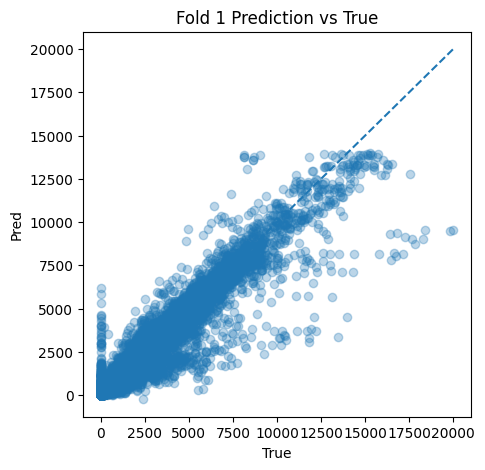

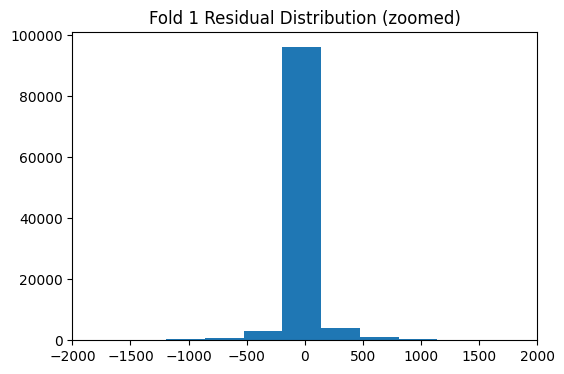

------------------------------------------------------------

Fold 2
Train: 2013-01-01 -> 2016-02-29
Valid: 2016-03-01 -> 2016-04-30
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4015
[LightGBM] [Info] Number of data points in the train set: 2052864, number of used features: 26
[LightGBM] [Info] Start training from score 310.151366
Fold 2 RMSE: 513.4299


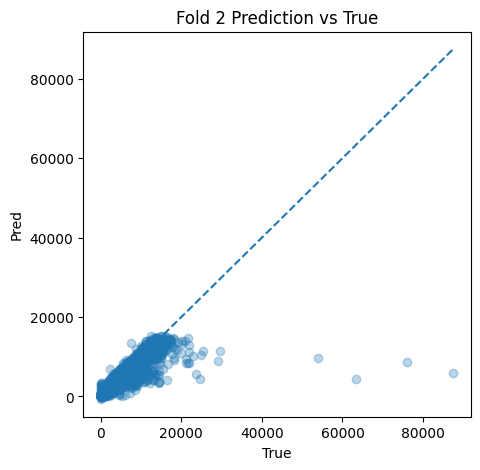

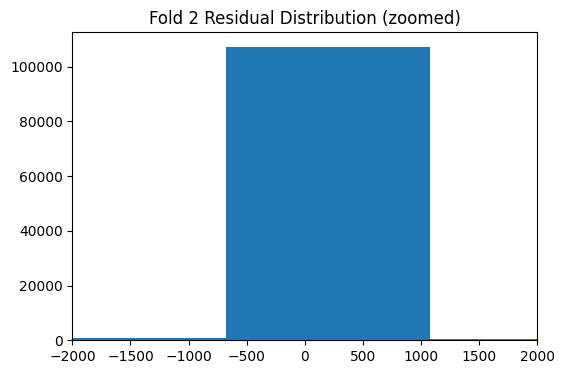

------------------------------------------------------------

Fold 3
Train: 2013-01-01 -> 2016-04-30
Valid: 2016-05-01 -> 2016-06-30
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4032
[LightGBM] [Info] Number of data points in the train set: 2161566, number of used features: 26
[LightGBM] [Info] Start training from score 317.266917
Fold 3 RMSE: 466.3783


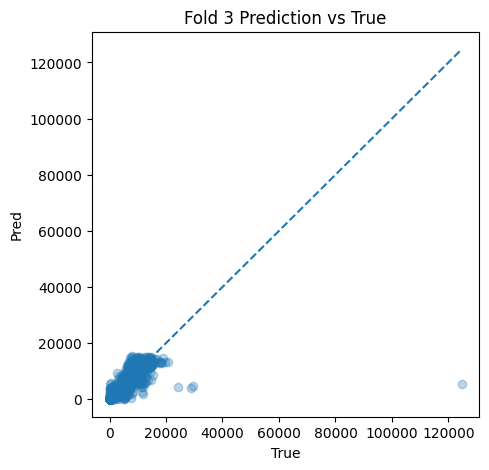

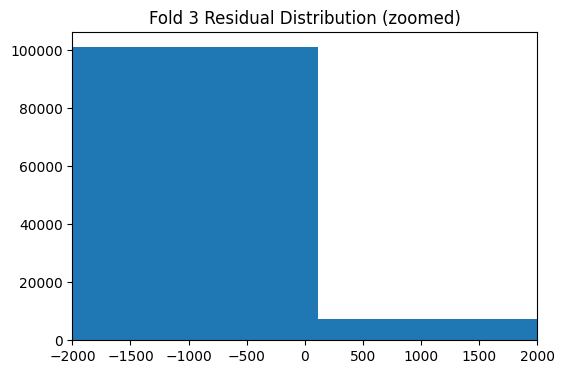

------------------------------------------------------------

Fold 4
Train: 2013-01-01 -> 2016-06-30
Valid: 2016-07-01 -> 2016-08-31
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4063
[LightGBM] [Info] Number of data points in the train set: 2270268, number of used features: 26
[LightGBM] [Info] Start training from score 322.773360
Fold 4 RMSE: 206.0251


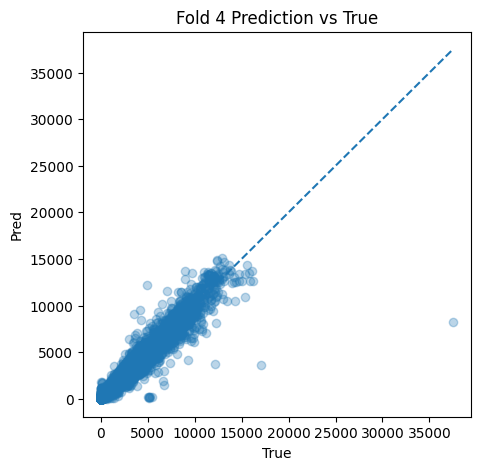

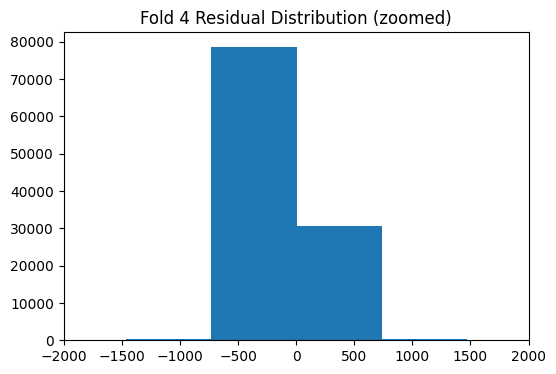

------------------------------------------------------------

Fold 5
Train: 2013-01-01 -> 2016-08-31
Valid: 2016-09-01 -> 2016-10-31
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4068
[LightGBM] [Info] Number of data points in the train set: 2380752, number of used features: 26
[LightGBM] [Info] Start training from score 327.080317
Fold 5 RMSE: 333.7182


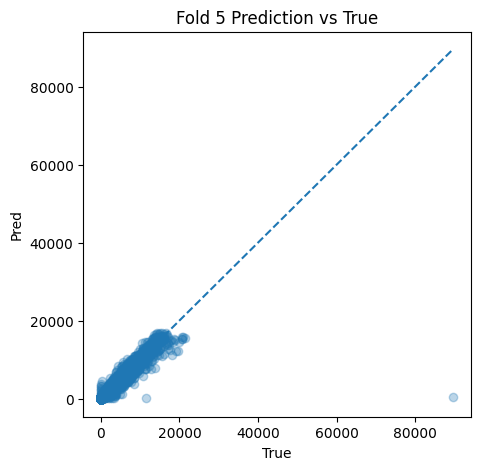

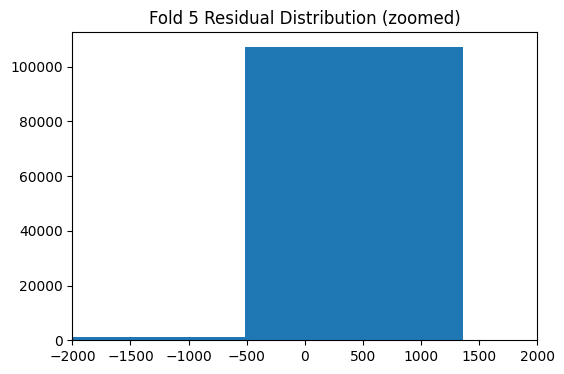

------------------------------------------------------------

Fold 6
Train: 2013-01-01 -> 2016-10-31
Valid: 2016-11-01 -> 2016-12-31
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4079
[LightGBM] [Info] Number of data points in the train set: 2489454, number of used features: 26
[LightGBM] [Info] Start training from score 331.456197
Fold 6 RMSE: 358.3531


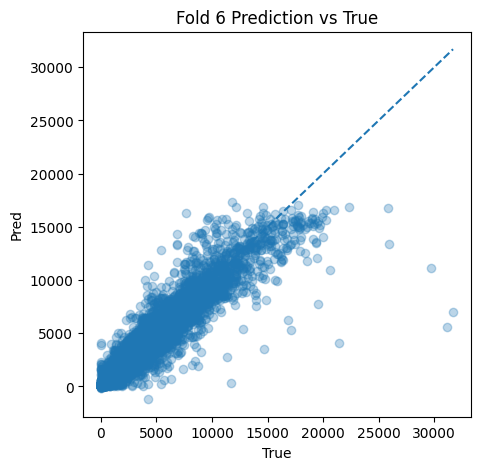

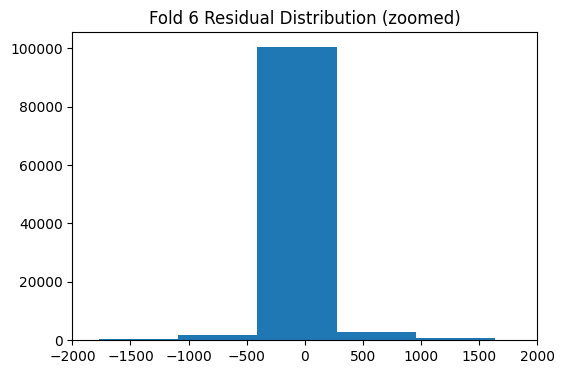

------------------------------------------------------------

CROSS-VALIDATION SUMMARY
Fold RMSEs: [np.float64(303.5396), np.float64(513.4299), np.float64(466.3783), np.float64(206.0251), np.float64(333.7182), np.float64(358.3531)]
Mean CV RMSE: 363.574
Std CV RMSE: 101.9558
OOF RMSE: 377.4702

Top 20 Features (mean importance across folds):
                       feature  importance_mean  importance_std
14                  sales_lag1       882.333333      355.425410
0                    store_nbr       874.833333      549.281779
15                  sales_lag7       787.666667      377.742711
3                    dayofweek       552.333333      273.613271
25         transactions_diff_1       507.500000      352.762786
22           transactions_lag1       447.333333      275.183979
16         sales_rolling_mean7       380.500000      189.244771
17                sales_diff_1       379.166667      265.301977
4                        month       364.666667      248.467749
23           tra

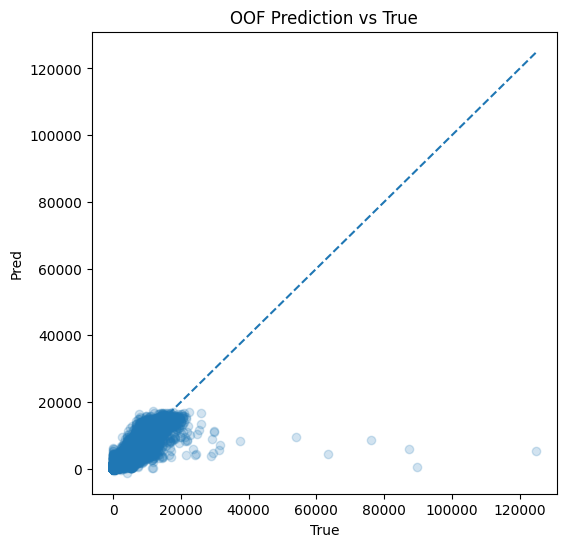

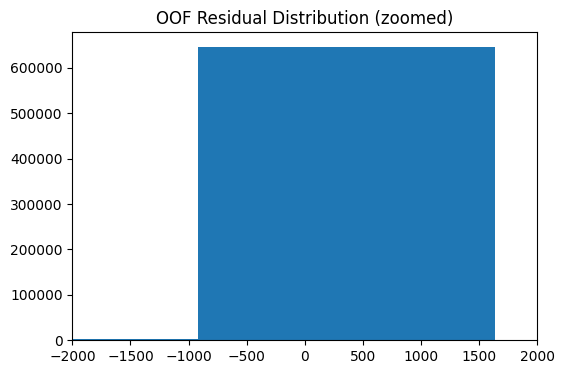


Top 10 Stores by Mean Absolute Error:
store_nbr
44    180.550095
45    171.722707
47    144.415101
46    136.399892
3     132.141086
49    127.137708
48    125.867385
20    121.588212
51    100.865317
11     94.138480
Name: abs_error, dtype: float64

Top 10 Families by Mean Absolute Error:
family
GROCERY I        660.182693
BEVERAGES        432.683431
PRODUCE          264.498803
CLEANING         187.407639
DAIRY            111.896919
MEATS             75.407249
POULTRY           70.267057
PERSONAL CARE     69.263701
BREAD/BAKERY      67.586307
FROZEN FOODS      53.577743
Name: abs_error, dtype: float64

Top 10 Largest Absolute Errors:
              date store_nbr     family       sales         pred  \
2163393 2016-05-02         2  GROCERY I  124717.000  5446.949950   
2446182 2016-10-07        39      MEATS   89576.360   455.593392   
2144385 2016-04-21        20  GROCERY I   87438.516  5850.798294   
2139864 2016-04-18        45  GROCERY I   76090.000  8756.722742   
2152701 2016-04-

C:\Users\cyuji\AppData\Local\Temp\ipykernel_36168\211608078.py:141: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_valid_df.groupby("store_nbr")["abs_error"]
C:\Users\cyuji\AppData\Local\Temp\ipykernel_36168\211608078.py:151: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_valid_df.groupby("family")["abs_error"]


In [2]:
params = {
    "objective": "regression",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": 42,
    "n_jobs": -1
}

fold_scores = []
oof_pred = np.zeros(len(df_feature))
oof_mask = np.zeros(len(df_feature), dtype=bool)

feature_importances = []
all_valid_parts = []

folds = [
    ("2013-01-01", "2015-12-31", "2016-01-01", "2016-02-29"),
    ("2013-01-01", "2016-02-29", "2016-03-01", "2016-04-30"),
    ("2013-01-01", "2016-04-30", "2016-05-01", "2016-06-30"),
    ("2013-01-01", "2016-06-30", "2016-07-01", "2016-08-31"),
    ("2013-01-01", "2016-08-31", "2016-09-01", "2016-10-31"),
    ("2013-01-01", "2016-10-31", "2016-11-01", "2016-12-31"),
]

for fold_id, (train_start, train_end, valid_start, valid_end) in enumerate(folds, start=1):
    print(f"\nFold {fold_id}")
    print(f"Train: {train_start} -> {train_end}")
    print(f"Valid: {valid_start} -> {valid_end}")

    train_mask = (df_feature["date"] >= train_start) & (df_feature["date"] <= train_end)
    valid_mask = (df_feature["date"] >= valid_start) & (df_feature["date"] <= valid_end)

    train_df = df_feature.loc[train_mask].copy()
    valid_df = df_feature.loc[valid_mask].copy()

    X_train = train_df.drop(columns=["date", "sales"])
    y_train = train_df["sales"]
    X_valid = valid_df.drop(columns=["date", "sales"])
    y_valid = valid_df["sales"]

    features = X_train.columns.tolist()

    model = LGBMRegressor(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0)
        ]
    )

    pred_valid = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, pred_valid))
    fold_scores.append(rmse)

    print(f"Fold {fold_id} RMSE: {rmse:.4f}")

    # OOF
    oof_pred[valid_df.index] = pred_valid
    oof_mask[valid_df.index] = True

    feature_importances.append(model.feature_importances_)

    valid_df["pred"] = pred_valid
    valid_df["residual"] = valid_df["sales"] - valid_df["pred"]
    valid_df["abs_error"] = valid_df["residual"].abs()
    valid_df["fold"] = fold_id
    all_valid_parts.append(valid_df)

    plt.figure(figsize=(5, 5))
    plt.scatter(y_valid, pred_valid, alpha=0.3)
    plt.xlabel("True")
    plt.ylabel("Pred")
    plt.title(f"Fold {fold_id} Prediction vs True")
    plt.plot(
        [y_valid.min(), y_valid.max()],
        [y_valid.min(), y_valid.max()],
        linestyle="--"
    )
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(valid_df["residual"], bins=50)
    plt.xlim(-2000, 2000)
    plt.title(f"Fold {fold_id} Residual Distribution (zoomed)")
    plt.show()

    print("-" * 60)


print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

print("Fold RMSEs:", [round(s, 4) for s in fold_scores])
print("Mean CV RMSE:", round(np.mean(fold_scores), 4))
print("Std CV RMSE:", round(np.std(fold_scores), 4))

# OOF RMSE
oof_rmse = np.sqrt(mean_squared_error(df_feature.loc[oof_mask, "sales"], oof_pred[oof_mask]))
print("OOF RMSE:", round(oof_rmse, 4))

all_valid_df = pd.concat(all_valid_parts, axis=0).sort_index()

importance_df = pd.DataFrame({
    "feature": features,
    "importance_mean": np.mean(feature_importances, axis=0),
    "importance_std": np.std(feature_importances, axis=0)
}).sort_values("importance_mean", ascending=False)

print("\nTop 20 Features (mean importance across folds):")
print(importance_df.head(20))

plt.figure(figsize=(6, 6))
plt.scatter(all_valid_df["sales"], all_valid_df["pred"], alpha=0.2)
plt.xlabel("True")
plt.ylabel("Pred")
plt.title("OOF Prediction vs True")
plt.plot(
    [all_valid_df["sales"].min(), all_valid_df["sales"].max()],
    [all_valid_df["sales"].min(), all_valid_df["sales"].max()],
    linestyle="--"
)
plt.savefig(Assets/"model_1.png",dpi=150, bbox_inches="tight")
plt.show()

#residual distribution
plt.figure(figsize=(6, 4))
plt.hist(all_valid_df["residual"], bins=50)
plt.xlim(-2000, 2000)
plt.title("OOF Residual Distribution (zoomed)")
plt.savefig(Assets/"model_2.png",dpi=150, bbox_inches="tight")
plt.show()

# store 误差汇总
store_error = (
    all_valid_df.groupby("store_nbr")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 Stores by Mean Absolute Error:")
print(store_error.head(10))

# family 误差汇总
family_error = (
    all_valid_df.groupby("family")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 Families by Mean Absolute Error:")
print(family_error.head(10))

# 最大误差样本
print("\nTop 10 Largest Absolute Errors:")
print(
    all_valid_df.sort_values("abs_error", ascending=False)[
        ["date", "store_nbr", "family", "sales", "pred", "residual", "abs_error", "fold"]
    ].head(10)
)


### Results

The model demonstrates consistent performance across folds, indicating stable generalization over time.

- Mean CV RMSE: 363.574
- OOF RMSE: 377.4702

The similarity between fold-level and OOF performance suggests that the model generalizes well across different temporal regimes.

###  Feature Importance Analysis

Based on the feature importance derived from the LightGBM model, the key drivers of sales prediction can be categorized into three hierarchical groups:

#### 1. Primary Drivers

- store_nbr  
- sales_lag1, sales_lag7  
- transactions_diff_1, transactions_lag1, transactions_lag7  

These features form the core predictive foundation of the model:

- **store_nbr** (encoded as categorical) captures structural differences across stores and acts as the most important segmentation dimension  
- **sales lag features** reflect strong temporal dependency, which is fundamental in time series forecasting  
- **transactions features** serve as a proxy for customer demand, directly influencing sales volume  

👉 This layer reveals the core modeling structure:

> Sales ≈ historical demand (inertia) + current demand (transactions) + store-specific effects

#### 2. Structural & Seasonal Factors

- dayofweek, month, sin_dow  
- sales_diff_1, sales_rolling_mean7  
- transactions_rolling_mean7  
- family  

These features act as structural adjustments to the base prediction:

- Time-based features (e.g., weekday, month) capture periodic patterns  
- Rolling and differencing features reflect short-term trend dynamics  
- **family (product category)** provides structural information about product composition and plays a moderately important role  

👉 Note:

> Product categories influence sales patterns, but are not the primary drivers of short-term fluctuations.

#### 3. Secondary / Perturbation Signals

- onpromotion_lag1, onpromotion_lag7  
- onpromotion_diff_1, onpromotion_rolling_mean7  
- is_holiday  
- store_baseline, family_baseline, family_ratio_hist  

These features contribute to the model but have relatively weaker overall impact:

- **promotion and holiday effects** influence sales but are not dominant drivers in this dataset  
- **baseline and ratio features** provide long-term structural signals, but are partially replaced by stronger lag and transaction features  

#### 4.Key Insights

- The model primarily relies on **temporal dependency (lag features)** and **demand signals (transactions)** for prediction  
- **store_nbr**, as a categorical feature, significantly improves model performance, indicating strong heterogeneity across stores  
- **family (product category)** has moderate importance, acting as a structural constraint rather than a short-term driver  
- **promotion and holiday effects** appear relatively weak in the current feature system, suggesting their impact may already be absorbed by other variables  
- Overall, the model follows a hybrid structure of:

> time-driven dynamics + structural adjustments

#### 5. Modeling Perspective

The model can be interpreted as an instance of **implicit hierarchical modeling**.

Store-level heterogeneity
        ↓
Product family structure
        ↓
Temporal dynamics (dominant)

In other words, the model first differentiates across stores, then captures variation within product category structures, and ultimately relies on temporal dynamics as the primary driver of prediction.




### Model Error Analysis and Behavioral Insights


#### Overall Performance

The model performs well within the normal sales range, effectively capturing the variation patterns of the majority of observations.  

However, in extreme high-sales scenarios, it exhibits clear underestimation, reflecting the typical challenge of predicting long-tail distributions.

#### Long-tail Distribution Characteristics


Extreme sales observations are primarily concentrated in food-related categories, particularly **GROCERY I**, and appear across multiple stores.  

This indicates that the phenomenon is **not driven by individual stores**, but rather originates from **category-level demand fluctuations**.

While the model performs stably in the normal range, it lacks features capable of capturing **demand triggering mechanisms** (e.g., promotion intensity, pre-holiday stocking behavior).  

As a result, systematic underestimation occurs in high-sales scenarios.

#### Error Structure Decomposition

Model errors can be broadly categorized into two types:

##### 1. Long-tail Errors (Low frequency, high impact)

- Mainly concentrated in categories such as **GROCERY I** and **BEVERAGES**  
- Caused by sudden spikes in demand  
- Occur infrequently but contribute significantly to overall RMSE  

##### 2. Systematic Errors (High frequency, moderate impact)

- Observed in categories such as **PRODUCE** and **CLEANING**  
- Manifest as persistent prediction bias  
- Indicate insufficient modeling of these categories  

In addition, certain stores (e.g., **store 45, 44, 20**) consistently exhibit higher errors across multiple time windows, suggesting more complex or volatile sales patterns.

#### Log Transformation Attempt

A log transformation was applied to the target variable to mitigate the long-tail distribution.

Although the residual distribution became more symmetric after transformation, the RMSE increased when converted back to the original sales scale.  

Moreover, an overall upward bias in predictions was observed.

Therefore, the final model retains the **original sales values as the target**, ensuring consistency between evaluation metrics and business objectives.

#### Residual Seasonality Analysis

An attempt was made to analyze residual patterns across the day-of-week dimension.  

However, results were inconsistent across different rolling windows, and no stable periodic bias was identified.  

Thus, this analysis was not included in the final conclusions.

### Key Conclusions

- The model performs stably within the normal sales range but systematically underestimates extreme demand scenarios  
- Prediction errors arise from both **long-tail shocks** and **insufficient category-level modeling**  
- The model is primarily driven by temporal dynamics, with limited ability to capture demand-triggering mechanisms  
- Future improvements should focus more on **trigger-based feature engineering**, rather than simply increasing model complexity  

## Limitations & Future Work

### Limitations

- The model is unable to capture sudden demand spikes (e.g., pre-holiday stocking behavior)  
- Lack of explicit features representing promotion intensity  
- Long-tail distribution leads to underestimation in high-sales scenarios  

### Future Work

- Incorporate event-based and holiday-related features to better capture demand triggers  
- Introduce segmented modeling strategies (e.g., separate models for low vs. high sales regimes)  

These directions suggest that improving feature representation is likely more impactful than increasing model complexity.

